In [1]:
import os
os.getcwd( )

'/Users/fengshuoliu/Library/CloudStorage/GoogleDrive-fl1357@nyu.edu/My Drive/Lab/Zhan/202308_IIA_combine_ic/analysis'

In [2]:
pwd

'/Users/fengshuoliu/Library/CloudStorage/GoogleDrive-fl1357@nyu.edu/My Drive/Lab/Zhan/202308_IIA_combine_ic/analysis'

In [3]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_17055/3777615979.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:
os.chdir('../')
#os.chdir('/home/humble_local2_25t/fengshuo/home/Single_cell/Lab/Deigo/')
#os.chdir('/home/humble_local2_25t/fengshuo/home/Single_cell/Lab/Liqun/202304-202308_neuts/')

In [4]:
pwd

'/Users/fengshuoliu/Library/CloudStorage/GoogleDrive-fl1357@nyu.edu/My Drive/Lab/Zhan/202308_IIA_combine_ic'

In [5]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from matplotlib.collections import PathCollection

In [6]:
adata = sc.read_h5ad('./data/merged/merged_with_sham.h5ad')  
#adata.obs['sample'] = adata.obs['surgery'].astype(str) + '_' + adata.obs['tissue'].astype(str) + '_' + adata.obs['biotin'].astype(str) + '_' + adata.obs['age'].astype(str) + '_' + adata.obs['replicate'].astype(str)
# Count the number of unique values in 'sample' column
#num_unique_samples = adata.obs['sample'].nunique()
#num_unique_samples

In [7]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,log10GenesPerUMI,mitoRatio,seq.ID,surgery,age,tissue,biotin,...,TAG_classification,TAG_classification.global,hash.ID,SCT_snn_res.0.5,sample,celltype_A,celltype_B,integrated_snn_res.1,integrated_snn_res.2,integrated_snn_res.5
AAACCCAGTCCTTAAG-1_1,XZ53974_XZ53974-A-Bone-neg-1,17462.0,3855,0.845343,0.035162,XZ53974_XZ53977,IC,A,bone marrow,neg,...,NA,NA,NA,NA,NA,Mo/Mφ/cDC,pro-Mo,15,12,45
AAACGAACACTGTGTA-1_1,XZ53974_XZ53974-A-Bone-neg-1,6010.0,1147,0.809649,0.001331,XZ53974_XZ53977,IC,A,bone marrow,neg,...,NA,NA,NA,NA,NA,Nφ,Nφ,4,29,3
AAACGAAGTACTGGGA-1_1,XZ53974_XZ53974-A-Bone-neg-1,6131.0,1258,0.818391,0.004730,XZ53974_XZ53977,IC,A,bone marrow,neg,...,NA,NA,NA,NA,NA,Nφ,Nφ,4,29,21
AAACGCTAGGATTTCC-1_1,XZ53974_XZ53974-A-Bone-neg-1,9031.0,2714,0.868008,0.002325,XZ53974_XZ53977,IC,A,bone marrow,neg,...,NA,NA,NA,NA,NA,Mo/Mφ/cDC,Mo/Mφ,23,21,40
AAACGCTAGTGGTTCT-1_1,XZ53974_XZ53974-A-Bone-neg-1,20027.0,2769,0.800240,0.002946,XZ53974_XZ53977,IC,A,bone marrow,neg,...,NA,NA,NA,NA,NA,Nφ,Nφ,6,16,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGCGCTCTGTCTCG-1_44,TotalSeqC-Y-Bone-pos-3-iia,628.0,485,NaN,NaN,TotalSeqC,IIA,Y,bone marrow,pos,...,CMO305,Singlet,CMO305,16,y3,Mo/Mφ/cDC,Mφ,3,6,11
TTTGGTTTCTGTTTGT-1_44,TotalSeqC-Y-Bone-pos-3-iia,640.0,509,NaN,NaN,TotalSeqC,IIA,Y,bone marrow,pos,...,CMO305,Singlet,CMO305,16,y3,Mo/Mφ/cDC,Mφ,3,6,11
TTTGTCAAGGACACCA-1_44,TotalSeqC-Y-Bone-pos-3-iia,6256.0,2684,NaN,NaN,TotalSeqC,IIA,Y,bone marrow,pos,...,CMO305,Singlet,CMO305,5,y3,Mo/Mφ/cDC,Mφ,19,24,27
TTTGTCATCCCAAGTA-1_44,TotalSeqC-Y-Bone-pos-3-iia,628.0,329,NaN,NaN,TotalSeqC,IIA,Y,bone marrow,pos,...,CMO305,Singlet,CMO305,18,y3,Nφ,Nφ,8,15,14


In [9]:
adata.write('./data/merged/merged_with_sham.h5ad')  

In [45]:
print(adata.obs)

                                         orig.ident  nCount_RNA  nFeature_RNA  \
AAACCCAGTCCTTAAG-1_1   XZ53974_XZ53974-A-Bone-neg-1     17462.0          3855   
AAACGAACACTGTGTA-1_1   XZ53974_XZ53974-A-Bone-neg-1      6010.0          1147   
AAACGAAGTACTGGGA-1_1   XZ53974_XZ53974-A-Bone-neg-1      6131.0          1258   
AAACGCTAGGATTTCC-1_1   XZ53974_XZ53974-A-Bone-neg-1      9031.0          2714   
AAACGCTAGTGGTTCT-1_1   XZ53974_XZ53974-A-Bone-neg-1     20027.0          2769   
...                                             ...         ...           ...   
TTTGCGCTCTGTCTCG-1_44    TotalSeqC-Y-Bone-pos-3-iia       628.0           485   
TTTGGTTTCTGTTTGT-1_44    TotalSeqC-Y-Bone-pos-3-iia       640.0           509   
TTTGTCAAGGACACCA-1_44    TotalSeqC-Y-Bone-pos-3-iia      6256.0          2684   
TTTGTCATCCCAAGTA-1_44    TotalSeqC-Y-Bone-pos-3-iia       628.0           329   
TTTGTCATCTGCTGCT-1_44    TotalSeqC-Y-Bone-pos-3-iia      4763.0          1438   

                       log1

In [63]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
hvgs = adata.var['highly_variable']

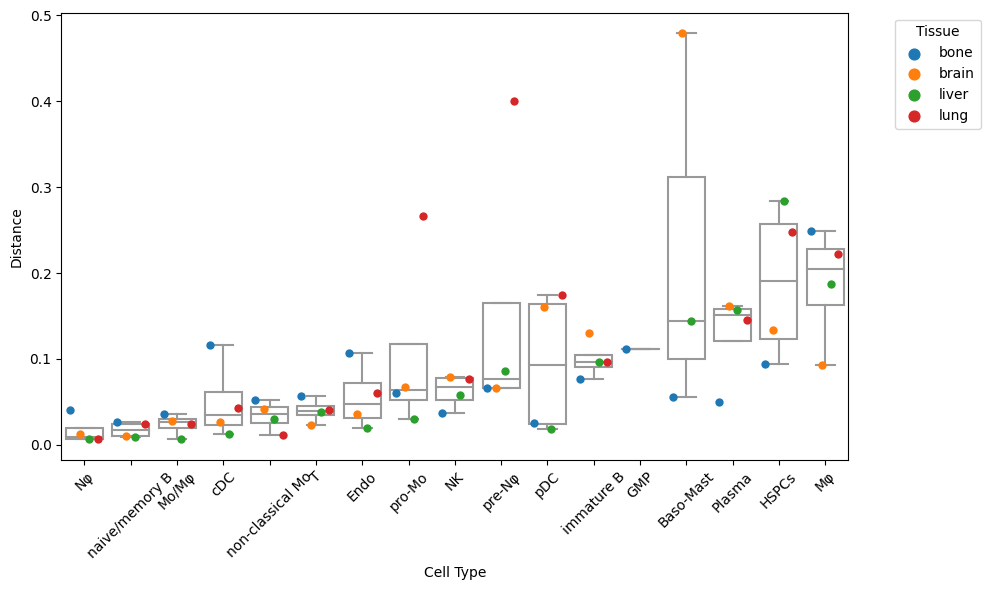

In [130]:
import scanpy as sc
import pandas as pd
from sklearn.metrics import pairwise_distances
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocess data
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Calculate pseudobulk profiles
pseudobulk = adata.to_df().groupby([adata.obs['celltype_B'], adata.obs['biotin'], adata.obs['tissue']]).mean()

# Calculate expression differences
hvgs = adata.var['highly_variable']
expr_diff = {}

for celltype in adata.obs.celltype_B.unique():
    for tissue in adata.obs.tissue.unique():
        try:
            cell_df = pseudobulk.loc[celltype, :, tissue]
            neg_values = cell_df.loc['neg']
            pos_values = cell_df.loc['pos']
            top_hvgs = hvgs.loc[hvgs].index

            # Filter out genes with NaN values
            valid_hvgs = top_hvgs[neg_values[top_hvgs].notna() & pos_values[top_hvgs].notna()]

            # Check if any valid genes are left after filtering
            if valid_hvgs.empty:
                continue

            dist = pairwise_distances(neg_values[valid_hvgs].values.reshape(1, -1), 
                                      pos_values[valid_hvgs].values.reshape(1, -1), 
                                      metric='correlation')
            expr_diff[(celltype, tissue)] = dist[0][0]

        except KeyError:
            pass
        
# Convert results to a dataframe
df = pd.DataFrame({
    'celltype': [ct for ct, _ in expr_diff.keys()],
    'tissue': [ts for _, ts in expr_diff.keys()],
    'distance': list(expr_diff.values())
})

# Calculate median distances for each celltype and sort celltypes by their median distances
sorted_celltypes = df.groupby('celltype')['distance'].median().sort_values(ascending=True).index.tolist()
df['celltype'] = pd.Categorical(df['celltype'], categories=sorted_celltypes, ordered=True)

# Create a plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='celltype', y='distance', color='white', fliersize=0, order=sorted_celltypes)
sns.stripplot(data=df, x='celltype', y='distance', hue='tissue', jitter=True, dodge=True, size=6, order=sorted_celltypes)
plt.xlabel('Cell Type')
plt.ylabel('Distance')
plt.legend(title='Tissue', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("./outs/iia_ic_merged/Expression_distance_ALL_boxplot_sorted_by_median.pdf", dpi=300, format='pdf')
plt.show()

/Users/fengshuoliu/anaconda3/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/var/folders/37/xlq517ls2276293h4xc51ydc0000gn/T/ipykernel_37185/242833615.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pseudobulk = adata.to_df().groupby([adata.obs['celltype_B'], adata.obs['biotin'], adata.obs['tissue']]).mean()
/Users/fengshuoliu/anaconda3/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1103: RuntimeWarning: divide by zero encountered in divide
  var *= np.divide(n, n-dd

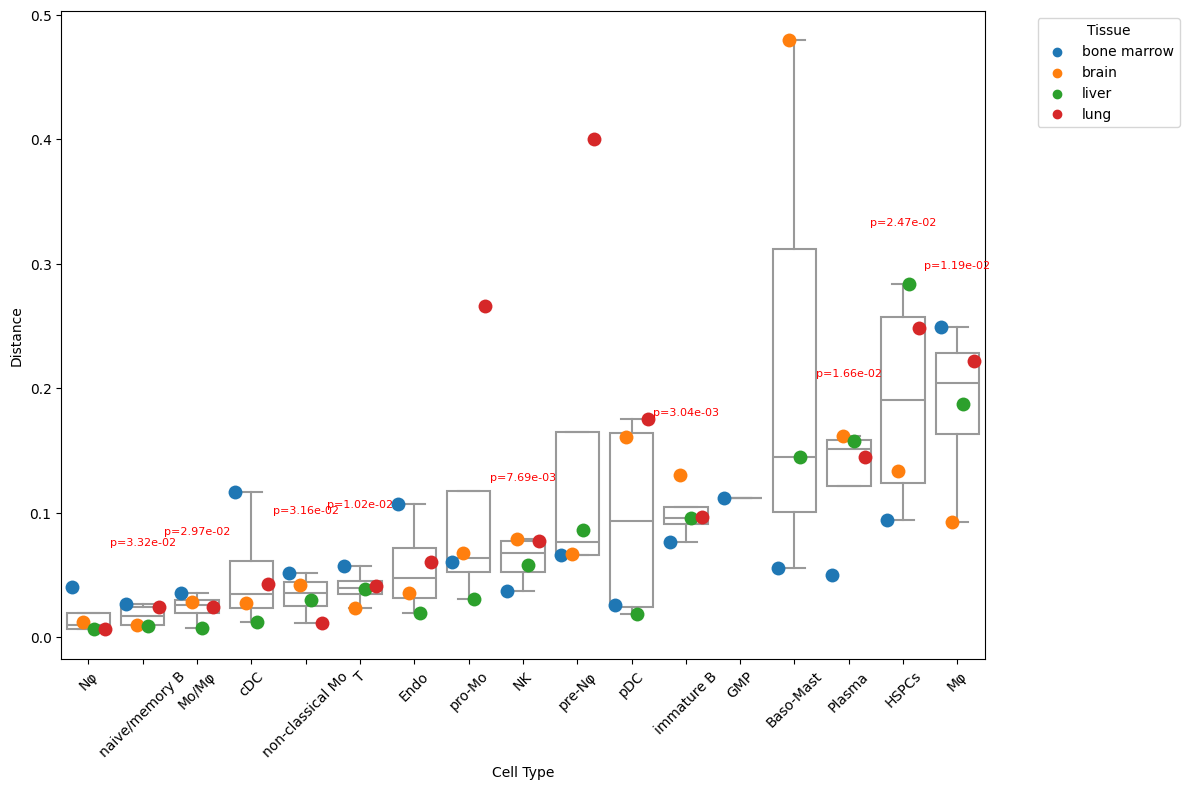

In [11]:
import scanpy as sc
import pandas as pd
from sklearn.metrics import pairwise_distances
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp

# Preprocess data
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# Calculate pseudobulk profiles
pseudobulk = adata.to_df().groupby([adata.obs['celltype_B'], adata.obs['biotin'], adata.obs['tissue']]).mean()

# Calculate expression differences
hvgs = adata.var['highly_variable']
expr_diff = {}

for celltype in adata.obs.celltype_B.unique():
    for tissue in adata.obs.tissue.unique():
        try:
            cell_df = pseudobulk.loc[celltype, :, tissue]
            neg_values = cell_df.loc['neg']
            pos_values = cell_df.loc['pos']
            top_hvgs = hvgs.loc[hvgs].index

            # Filter out genes with NaN values
            valid_hvgs = top_hvgs[neg_values[top_hvgs].notna() & pos_values[top_hvgs].notna()]

            # Check if any valid genes are left after filtering
            if valid_hvgs.empty:
                continue

            dist = pairwise_distances(neg_values[valid_hvgs].values.reshape(1, -1), 
                                      pos_values[valid_hvgs].values.reshape(1, -1), 
                                      metric='correlation')
            expr_diff[(celltype, tissue)] = dist[0][0]
        except KeyError:
            pass

# Convert results to a dataframe
df = pd.DataFrame({
    'celltype': [ct for ct, _ in expr_diff.keys()],
    'tissue': [ts for _, ts in expr_diff.keys()],
    'distance': list(expr_diff.values())
})

# Rank cell types by median distance
sorted_celltypes = df.groupby('celltype')['distance'].median().sort_values(ascending=True).index.tolist()

# Compute p-values for each cell type based on one-sample t-test against 0
p_values = {}
for celltype in sorted_celltypes:
    distances = df.loc[df['celltype'] == celltype, 'distance']
    _, p_value = ttest_1samp(distances, 0)
    if p_value < 0.05:
        p_values[celltype] = p_value

# Create a plot
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='celltype', y='distance', color='white', fliersize=0, order=sorted_celltypes)
sns.stripplot(data=df, x='celltype', y='distance', hue='tissue', jitter=True, dodge=True, size=10, order=sorted_celltypes)

# Annotate the plot with significant p-values
for idx, celltype in enumerate(sorted_celltypes):
    if celltype in p_values:
        y_position = df.loc[df['celltype'] == celltype, 'distance'].max() + 0.05  # adjust 0.05 accordingly
        plt.text(idx, y_position, f"p={p_values[celltype]:.2e}", ha='center', va='center', color='red', size=8)

plt.xlabel('Cell Type')
plt.ylabel('Distance')
plt.legend(title='Tissue', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

#plt.savefig("./outs/iia_ic_merged/Expression_distance_ALL_boxplot_sorted_by_median_with_pvalues.pdf", dpi=300, format='pdf')
plt.show()
